In [1]:
import pandas as pd
import numpy as np
RANDOM_SEED = 694973

In [2]:
df=pd.read_csv('baseline_probs.csv')
df['is_made'] = np.where(df['shotResult']=='Made',1,0)
df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,defTeamId,defTeamTricode,SEASON,distance,angle,shot_type,is_behind_backboard,logits,probs,is_made
0,22100001,7,PT11M42.00S,1,1610612749,MIL,1628960,Allen,G. Allen,-164,...,NaN,NaN,2021-22,0.313120,0.213808,JUMPER,0,-0.616470,0.350585,0
1,22100001,15,PT11M13.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,0,...,NaN,NaN,2021-22,0.309065,0.000956,JUMPER,0,-0.628800,0.347783,0
2,22100001,18,PT11M01.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,5,...,NaN,NaN,2021-22,0.172847,0.010751,JUMPER,0,-0.166844,0.458385,0
3,22100001,20,PT10M47.00S,1,1610612751,BKN,1629651,Claxton,N. Claxton,1,...,NaN,NaN,2021-22,0.004845,0.122509,DUNK,0,1.929864,0.873234,1
4,22100001,22,PT10M31.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,15,...,NaN,NaN,2021-22,0.123481,0.045895,HOOK,0,-0.200741,0.449983,0


In [3]:
df.columns

Index(['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode',
       'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy',
       'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway',
       'pointsTotal', 'location', 'description', 'actionType', 'subType',
       'videoAvailable', 'shotValue', 'actionId', 'GAME_ID', 'homeTeamId',
       'homeTeamTricode', 'awayTeamId', 'awayTeamTricode', 'defTeamId',
       'defTeamTricode', 'SEASON', 'distance', 'angle', 'shot_type',
       'is_behind_backboard', 'logits', 'probs', 'is_made'],
      dtype='str')

In [4]:
players = pd.read_csv("nba_api_code/nba_player_attributes.csv")
players = players.drop_duplicates(subset=["PLAYER_ID"])
print(players.head())
print(players.shape)

       TeamID   SEASON  LeagueID          PLAYER NICKNAME     PLAYER_SLUG  \
0  1610612737  2021-22         0    Delon Wright    Delon    delon-wright   
1  1610612737  2021-22         0   Jalen Johnson    Jalen   jalen-johnson   
2  1610612737  2021-22         0  Sharife Cooper  Sharife  sharife-cooper   
3  1610612737  2021-22         0   Kevin Huerter    Kevin   kevin-huerter   
4  1610612737  2021-22         0     Skylar Mays   Skylar     skylar-mays   

   NUM POSITION HEIGHT  WEIGHT    BIRTH_DATE   AGE EXP           SCHOOL  \
0  0.0        G    6-5   185.0  APR 26, 1992  30.0   6             Utah   
1  1.0        F    6-8   219.0  DEC 18, 2001  20.0   R             Duke   
2  2.0        G    6-1   176.0  JUN 11, 2001  21.0   R           Auburn   
3  3.0      G-F    6-7   198.0  AUG 27, 1998  23.0   3         Maryland   
4  4.0        G    6-4   205.0  SEP 05, 1997  24.0   1  Louisiana State   

   PLAYER_ID            HOW_ACQUIRED  HEIGHT_INCHES  
0    1626153                    

In [5]:
df['personId']=pd.to_numeric(df['personId'])
cdf=df.merge(players[['PLAYER','POSITION','BIRTH_DATE','PLAYER_ID','HEIGHT_INCHES']],how='left',left_on=['personId'],right_on=['PLAYER_ID'])
cdf.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,shot_type,is_behind_backboard,logits,probs,is_made,PLAYER,POSITION,BIRTH_DATE,PLAYER_ID,HEIGHT_INCHES
0,22100001,7,PT11M42.00S,1,1610612749,MIL,1628960,Allen,G. Allen,-164,...,JUMPER,0,-0.616470,0.350585,0,Grayson Allen,G,"OCT 08, 1995",1628960.0,76.0
1,22100001,15,PT11M13.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,0,...,JUMPER,0,-0.628800,0.347783,0,Giannis Antetokounmpo,F,"DEC 06, 1994",203507.0,83.0
2,22100001,18,PT11M01.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,5,...,JUMPER,0,-0.166844,0.458385,0,Giannis Antetokounmpo,F,"DEC 06, 1994",203507.0,83.0
3,22100001,20,PT10M47.00S,1,1610612751,BKN,1629651,Claxton,N. Claxton,1,...,DUNK,0,1.929864,0.873234,1,Nic Claxton,F-C,"APR 17, 1999",1629651.0,83.0
4,22100001,22,PT10M31.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,15,...,HOOK,0,-0.200741,0.449983,0,Giannis Antetokounmpo,F,"DEC 06, 1994",203507.0,83.0


In [6]:
cdf.loc[cdf['PLAYER_ID'].isna()]

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,shot_type,is_behind_backboard,logits,probs,is_made,PLAYER,POSITION,BIRTH_DATE,PLAYER_ID,HEIGHT_INCHES
124,22100001,457,PT04M12.00S,3,1610612749,MIL,1629620,Robinson,J. Robinson,123,...,JUMPER,0,-0.604370,0.353344,0,NaN,NaN,NaN,NaN,NaN
182,22100001,669,PT01M23.00S,4,1610612749,MIL,1629620,Robinson,J. Robinson,234,...,JUMPER,0,-0.466552,0.385433,1,NaN,NaN,NaN,NaN,NaN
184,22100001,680,PT00M56.50S,4,1610612749,MIL,1630686,Kalaitzakis,B. Kalaitzakis,17,...,LAYUP,0,-0.257237,0.436043,0,NaN,NaN,NaN,NaN,NaN
185,22100001,682,PT00M55.00S,4,1610612749,MIL,1630686,Kalaitzakis,B. Kalaitzakis,0,...,LAYUP,0,0.690075,0.665983,0,NaN,NaN,NaN,NaN,NaN
624,22100004,151,PT00M58.20S,1,1610612741,CHI,1628993,Johnson,A. Johnson,-17,...,LAYUP,0,0.665242,0.660437,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082879,22501194,657,PT01M42.00S,4,1610612763,MEM,1643253,Okani,T. Okani,-53,...,JUMPER,0,-0.318633,0.421009,0,NaN,NaN,NaN,NaN,NaN
1082881,22501194,661,PT01M08.00S,4,1610612763,MEM,1643253,Okani,T. Okani,230,...,JUMPER,0,-0.458316,0.387385,0,NaN,NaN,NaN,NaN,NaN
1084528,22501203,588,PT04M27.00S,4,1610612756,PHX,1628502,Hayes-Davis,N. Hayes-Davis,206,...,JUMPER,0,-0.560124,0.363519,0,NaN,NaN,NaN,NaN,NaN
1084544,22501203,625,PT00M35.60S,4,1610612756,PHX,1628502,Hayes-Davis,N. Hayes-Davis,157,...,JUMPER,0,-0.544332,0.367180,0,NaN,NaN,NaN,NaN,NaN


In [7]:
players.loc[players['PLAYER'].str.contains("Coo", case=False)][['PLAYER','PLAYER_ID']].drop_duplicates(['PLAYER_ID'])

,PLAYER,PLAYER_ID
2,Sharife Cooper,1630536
83,Tyler Cook,1629076
968,Xavier Cooks,1641645
1368,Scoot Henderson,1630703
2184,Cooper Flagg,1642843


In [8]:
print(cdf.shape)
cdf = cdf.loc[(cdf['BIRTH_DATE'].notna()) & (cdf['HEIGHT_INCHES'].notna()) & (cdf['PLAYER_ID'].notna())].reset_index(drop=True)
print(cdf.shape)

(1089418, 44)
(1085031, 44)


In [9]:
cdf["birthdate"] = pd.to_datetime(cdf["BIRTH_DATE"], format="%b %d, %Y")
cdf["season_end_year"] = cdf["SEASON"].str.split("-").str[0].astype(int) + 1
cdf["season_date"] = pd.to_datetime(cdf["season_end_year"].astype(str) + "-07-31")
cdf["player_age"] = (cdf["season_date"] - cdf["birthdate"]).dt.days / 365.25
cdf.loc[cdf['personId']==1628960][['SEASON','player_age']].head()

,SEASON,player_age
0,2021-22,26.811773
26,2021-22,26.811773
58,2021-22,26.811773
68,2021-22,26.811773
72,2021-22,26.811773


<Axes: >

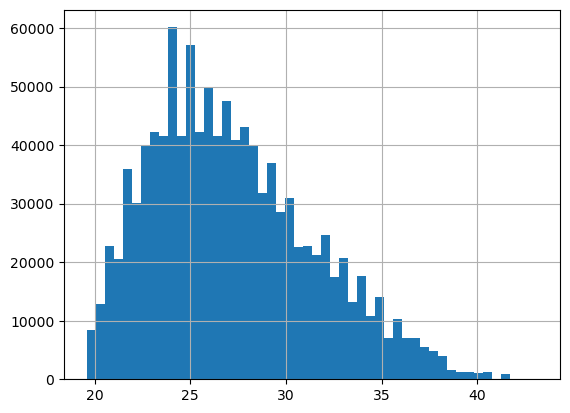

In [10]:
cdf["player_age"].hist(bins=50)

In [11]:
cdf['player_full_id'] = cdf['PLAYER'] + " (" + cdf['PLAYER_ID'].astype(int).astype(str) + ")"
# standardize age
age_mean = np.mean(cdf['player_age'])
age_std = np.std(cdf['player_age'])
cdf['age_z'] = (cdf['player_age'] - age_mean)/age_std
# standardize height
height_mean = np.mean(cdf['HEIGHT_INCHES'])
height_std = np.std(cdf['HEIGHT_INCHES'])
cdf['height_z'] = (cdf['HEIGHT_INCHES'] - height_mean)/height_std
# position remap
cdf['posit'] = cdf['POSITION'].str.split('-').str[0]
cdf = cdf.reset_index(drop=True)
cdf.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,PLAYER_ID,HEIGHT_INCHES,birthdate,season_end_year,season_date,player_age,player_full_id,age_z,height_z,posit
0,22100001,7,PT11M42.00S,1,1610612749,MIL,1628960,Allen,G. Allen,-164,...,1628960.0,76.0,1995-10-08,2022,2022-07-31,26.811773,Grayson Allen (1628960),-0.090909,-0.728069,G
1,22100001,15,PT11M13.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,0,...,203507.0,83.0,1994-12-06,2022,2022-07-31,27.649555,Giannis Antetokounmpo (203507),0.105817,1.480593,F
2,22100001,18,PT11M01.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,5,...,203507.0,83.0,1994-12-06,2022,2022-07-31,27.649555,Giannis Antetokounmpo (203507),0.105817,1.480593,F
3,22100001,20,PT10M47.00S,1,1610612751,BKN,1629651,Claxton,N. Claxton,1,...,1629651.0,83.0,1999-04-17,2022,2022-07-31,23.288159,Nic Claxton (1629651),-0.918316,1.480593,F
4,22100001,22,PT10M31.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,15,...,203507.0,83.0,1994-12-06,2022,2022-07-31,27.649555,Giannis Antetokounmpo (203507),0.105817,1.480593,F


In [12]:
agg = cdf.groupby(['player_full_id','SEASON','shot_type',
                   'PLAYER_ID', 'PLAYER', 'player_age', 'age_z', 'HEIGHT_INCHES', 'height_z','birthdate','posit']
                   ).agg(
        attempts=('is_made', 'size'),
        actual_makes=('is_made', 'sum'),
        expected_makes=('probs', 'sum'),
    ).reset_index()
agg['offset'] = np.log(agg['expected_makes'] / (agg['attempts'] - agg['expected_makes']))
agg.head(10)

,player_full_id,SEASON,shot_type,PLAYER_ID,PLAYER,player_age,age_z,HEIGHT_INCHES,height_z,birthdate,posit,attempts,actual_makes,expected_makes,offset
0,A.J. Lawson (1630639),2022-23,DUNK,1630639.0,A.J. Lawson,23.041752,-0.976176,78.0,-0.097023,2000-07-15,G,6,5,4.606923,1.196045
1,A.J. Lawson (1630639),2022-23,JUMPER,1630639.0,A.J. Lawson,23.041752,-0.976176,78.0,-0.097023,2000-07-15,G,27,12,10.200240,-0.498953
2,A.J. Lawson (1630639),2022-23,LAYUP,1630639.0,A.J. Lawson,23.041752,-0.976176,78.0,-0.097023,2000-07-15,G,11,5,6.662227,0.429093
3,A.J. Lawson (1630639),2023-24,DUNK,1630639.0,A.J. Lawson,24.043806,-0.740877,78.0,-0.097023,2000-07-15,G,13,12,9.504221,1.000180
4,A.J. Lawson (1630639),2023-24,JUMPER,1630639.0,A.J. Lawson,24.043806,-0.740877,78.0,-0.097023,2000-07-15,G,62,15,23.988975,-0.460282
5,A.J. Lawson (1630639),2023-24,LAYUP,1630639.0,A.J. Lawson,24.043806,-0.740877,78.0,-0.097023,2000-07-15,G,46,27,28.212996,0.461315
6,A.J. Lawson (1630639),2024-25,DUNK,1630639.0,A.J. Lawson,25.043121,-0.506220,78.0,-0.097023,2000-07-15,G,14,11,9.627423,0.789263
7,A.J. Lawson (1630639),2024-25,JUMPER,1630639.0,A.J. Lawson,25.043121,-0.506220,78.0,-0.097023,2000-07-15,G,106,33,39.452497,-0.522819
8,A.J. Lawson (1630639),2024-25,LAYUP,1630639.0,A.J. Lawson,25.043121,-0.506220,78.0,-0.097023,2000-07-15,G,70,36,41.499993,0.375789
9,A.J. Lawson (1630639),2025-26,DUNK,1630639.0,A.J. Lawson,26.042437,-0.271562,78.0,-0.097023,2000-07-15,G,4,3,2.848839,0.906141


In [13]:
agg.shape

(9598, 15)

In [14]:
agg.to_csv('projection_data.csv', index=False)

In [15]:
# # remove any games that have a missing home or away team ID
# missing_ids=df.loc[(df['homeTeamId'].isna())|(df['awayTeamId'].isna())]
# missing_game_ids = missing_ids['gameId']
# df = df.loc[~df['gameId'].isin(missing_game_ids)]
# print(df.shape)

In [16]:
# def define_defensive_team(homeTeamId, homeTeamTricode, awayTeamId, awayTeamTricode,ishome_shooter):
#     if ishome_shooter==1:
#         team_id = awayTeamId
#         team_tri = awayTeamTricode
#     else:
#         team_id = homeTeamId
#         team_tri = homeTeamTricode
#     return team_id, team_tri

# df[["defTeamId", "defTeamTricode"]] = df.apply(
#     lambda row: define_defensive_team(
#         row.homeTeamId,
#         row.homeTeamTricode,
#         row.awayTeamId,
#         row.awayTeamTricode,
#         row.ishome_shooter
#     ),
#     axis=1,
#     result_type="expand"  # ensures the tuple is split into multiple columns
# )
# df[['teamTricode','homeTeamTricode','awayTeamTricode','playerNameI','ishome_shooter','defTeamId','defTeamTricode']]

In [17]:
# data_model=cdf[['gameId','event_id','actionId','actionNumber','description',
#                 'is_made','distance','angle','xLegacy','yLegacy','shotValue', # shot info
#                 'subType','shot_type', # shot categorical info
#                 'SEASON', # season
#                 'PLAYER','PLAYER_ID','player_age', 'age_z'
#                 'HEIGHT_INCHES', # player info
#                 'POSITION', # positional info
#                 'homeTeamId','homeTeamTricode',# home team info
#                 'awayTeamId','awayTeamTricode',
#                 'defTeamId','defTeamTricode', # defensive team info
#                 'ishome_shooter','teamId','teamTricode' # shooter team Info
#                 ]].reset_index(drop=True)
# cdf.columns.difference(data_model.columns)